In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

plt.rcParams.update({
    'figure.figsize': (10, 5),
    'figure.dpi': 110,
    'axes.facecolor': '#1e1e1e',
    'figure.facecolor': '#222222',
    'axes.edgecolor': 'white',
    'axes.labelcolor': 'white',
    'xtick.color': 'white',
    'ytick.color': 'white',
    'text.color': 'white',
    'axes.titlecolor': 'white',
    'savefig.bbox': 'tight',
    'savefig.dpi': 140,
})
PALETTE = ['#4096ee', '#d6399f', '#39ced6']

DATA = Path('../data/raw/Telco-Customer-Churn.csv')
FIG  = Path('../figures'); FIG.mkdir(exist_ok=True)

df = pd.read_csv(DATA)
print(df.shape)
df.head(3)


(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes


In [3]:
df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

In [11]:
df['TotalCharges']= pd.to_numeric(df['TotalCharges'], errors='coerce')
print('TotalCharges nulls after coerce:' , df['TotalCharges'].isnull().sum())

TotalCharges nulls after coerce: 11


Churn
No     0.735
Yes    0.265
Name: proportion, dtype: float64


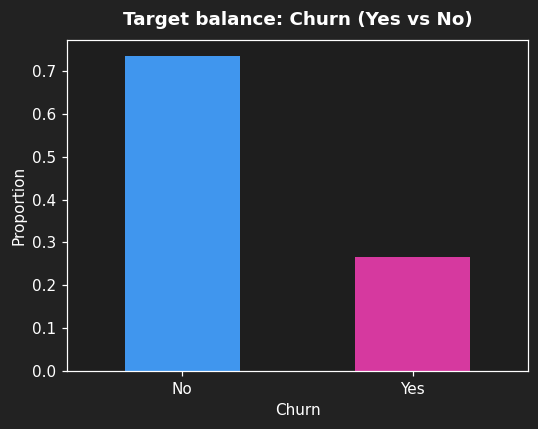

In [12]:
df['Churn'] = (df['Churn'].astype(str) == 'Yes').astype(int)
balance = df['Churn'].value_counts(normalize=True).rename({0: 'No', 1: 'Yes'})
print(balance.round(3))

fig, ax = plt.subplots(figsize=(5, 4))
balance.plot(kind='bar', color=PALETTE[:2], ax=ax)
ax.set_title('Target balance: Churn (Yes vs No)', weight='bold', pad=10)
ax.set_ylabel('Proportion')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.savefig(FIG / '00-class-balance.png')
plt.show()


### Numeric feature distributions

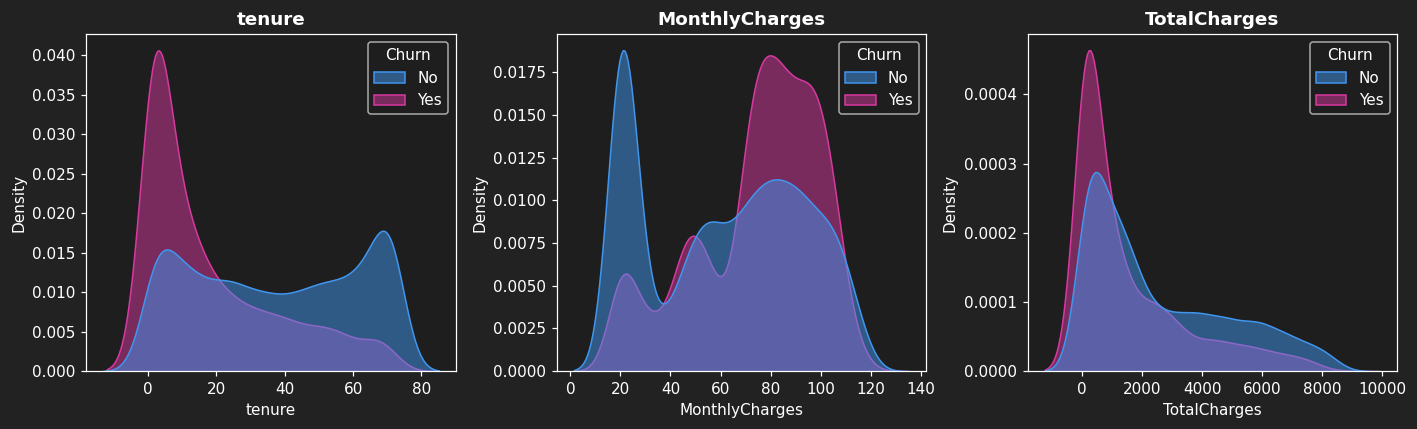

In [13]:
numeric = ['tenure', 'MonthlyCharges', 'TotalCharges']
churn_label = df['Churn'].map({0: 'No', 1: 'Yes'})
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

for ax, col in zip(axes, numeric):
    sns.kdeplot(data=df, x=col, hue=churn_label, hue_order=['No', 'Yes'],
                palette=PALETTE[:2], fill=True, alpha=0.5, ax=ax,
                common_norm=False)
    ax.set_title(col, weight='bold')

plt.tight_layout()
plt.savefig(FIG / '00-numeric-distributions.png')
plt.show()

###  Categorical lift

In [14]:
def churn_rate_by(col):
    return (df.groupby(col)['Churn']
              .agg(['mean', 'count'])
              .sort_values('mean', ascending=False)
              .rename(columns={'mean': 'churn_rate'}))

print(churn_rate_by('Contract').round(3), '\n')
print(churn_rate_by('InternetService').round(3), '\n')
print(churn_rate_by('PaymentMethod').round(3))

                churn_rate  count
Contract                         
Month-to-month       0.427   3875
One year             0.113   1473
Two year             0.028   1695 

                 churn_rate  count
InternetService                   
Fiber optic           0.419   3096
DSL                   0.190   2421
No                    0.074   1526 

                           churn_rate  count
PaymentMethod                               
Electronic check                0.453   2365
Mailed check                    0.191   1612
Bank transfer (automatic)       0.167   1544
Credit card (automatic)         0.152   1522


### Correlation snapshot

In [15]:
view = df.assign(
    contract_m2m   = (df['Contract'] == 'Month-to-month').astype(int),
    fiber_optic    = (df['InternetService'] == 'Fiber optic').astype(int),
    e_check        = (df['PaymentMethod'] == 'Electronic check').astype(int),
)[['tenure', 'MonthlyCharges', 'TotalCharges',
   'contract_m2m', 'fiber_optic', 'e_check', 'Churn']]

corr = view.corr()['Churn'].drop('Churn').sort_values(key=abs, ascending=False)
print(corr.round(3))

contract_m2m      0.405
tenure           -0.352
fiber_optic       0.308
e_check           0.302
TotalCharges     -0.199
MonthlyCharges    0.193
Name: Churn, dtype: float64


contract_m2m = +0.405 (the strongest): month-to-month → more churn. Positive = risk factor.
tenure = −0.352: the minus sign means the opposite direction — more months as a customer → less churn. This matches your tenure KDE exactly (churners clustered at low tenure). Negative = protective factor.

### EDA takeaways

- 7,043 customers, **27% churn rate** → moderate class imbalance.
- `TotalCharges` arrives as a string with 11 blank rows → impute, don't drop.
- The three biggest churn drivers are **contract type**, **internet service** (fiber optic = expensive + churny), and **payment method** (electronic check = friction).
- `tenure` is a strong negative signal: < 6-month customers are 3–5× more likely to churn than > 24-month customers.
- We expect ROC-AUC in the **0.82–0.86** range for tabular models without heavy tuning.

In [16]:
import sys; sys.path.insert(0, '..')
from src.features import build_preprocessor, load_data

X, y = load_data('../data/raw/Telco-Customer-Churn.csv')
pre = build_preprocessor()
Xt = pre.fit_transform(X)
print('Input shape :', X.shape)
print('Output shape:', Xt.shape)
print('First 8 feature names:', list(pre.get_feature_names_out())[:8])

Input shape : (7043, 19)
Output shape: (7043, 46)
First 8 feature names: ['num__tenure', 'num__MonthlyCharges', 'num__TotalCharges', 'cat__gender_Female', 'cat__gender_Male', 'cat__SeniorCitizen_0', 'cat__SeniorCitizen_1', 'cat__Partner_No']
